# 04.2 — Fine-tuning de Transformers para categorías gruesas

Este cuaderno ejecuta el flujo completo: integra **todas las pasadas de scraping utilizables**, submuestrea `SEGURO`, divide por video, reentrena seis clasificadores clásicos y compara dos encoders compactos mediante fine-tuning completo. Los objetivos son exclusivamente las cinco categorías gruesas de daño; `SEGURO` se deriva cuando no se activa ninguna. Las etiquetas finas y los flags transversales permanecen sólo como referencia de auditoría.

**Ejecución recomendada:** manual, de arriba hacia abajo. Los clásicos funcionan como control rápido. MiniLM y E5 están en celdas separadas; cada una muestra barras `tqdm`, pérdida y ETA y guarda un checkpoint al mejorar. Puede detenerse entre modelos sin perder resultados.

## 0. Dependencias

El experimento usa PyTorch en CPU. PyTorch oficial no ofrece un backend OpenCL y las GPU AMD de esta máquina no están en la matriz ROCm vigente para Windows. fastText se ejecuta mediante su CLI oficial v0.9.2: la primera ejecución lo compila automáticamente con el `g++`/`mingw32-make` ya instalado en esta máquina. WSL2 está disponible, pero no tiene `g++` ni `make` y no es necesario.

In [1]:
%pip install -q "sentence-transformers>=5,<6" "transformers>=5,<6" "torch>=2.6,<3" "pandas>=2.2,<3" "numpy>=1.26,<3" "scikit-learn>=1.5,<2" "matplotlib>=3.9,<4" "tqdm>=4.67,<5" "joblib>=1.4,<2"

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import importlib
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, Markdown

cwd = Path.cwd().resolve()
for candidate in (cwd, *cwd.parents):
    if (candidate / 'scripts_auxiliares' / 'entrenar_transformers_gruesos.py').exists():
        ROOT = candidate
        break
else:
    raise FileNotFoundError('No se encontró la raíz del proyecto.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from scripts_auxiliares import entrenar_transformers_gruesos as tm
tm = importlib.reload(tm)

tm.set_reproducibility()
print('Raíz:', ROOT)
print('Modelos:', {k: v.model_id for k, v in tm.MODEL_SPECS.items()})
print('Máximo de épocas:', tm.MAX_EPOCHS, '| ratio SEGURO:daño:', f'{tm.SAFE_TO_DAMAGE_RATIO}:1')

def mostrar_analisis_operativo(analysis, comparadores=()):
    tabla = tm.operational_comparison_frame([*comparadores, analysis])
    display(tabla)
    auto_test = analysis['autonomous']['test']
    alert_val = analysis['human_review_alert']['validation']
    alert_test = analysis['human_review_alert']['test']
    display(pd.DataFrame({
        'escenario': ['Decisión autónoma', 'Alerta humana calibrada en validación', 'Alerta humana en test'],
        'precisión': [auto_test['precision'], alert_val['precision'], alert_test['precision']],
        'recall': [auto_test['recall'], alert_val['recall'], alert_test['recall']],
        'VPN': [auto_test['negative_predictive_value'], alert_val['negative_predictive_value'], alert_test['negative_predictive_value']],
        'proporción enviada a revisión': [auto_test['review_rate'], alert_val['review_rate'], alert_test['review_rate']],
        'falsos negativos': [auto_test['false_negatives'], alert_val['false_negatives'], alert_test['false_negatives']],
    }))
    display(pd.DataFrame(
        list(auto_test['category_recall'].items()), columns=['categoría', 'recall autónomo test']
    ))
    modo = analysis['recommended_operating_mode']
    mensaje = {
        'autonomous': 'Candidato autónomo, todavía sujeto a aprobación externa.',
        'human_review_alert_pilot': 'Apto sólo como alerta para un piloto con decisión humana final.',
        'research_only': 'No alcanza la puerta mínima para uso operativo.',
    }[modo]
    display(Markdown(f"**Conclusión provisional para {analysis['model_label']}:** {mensaje}"))

Raíz: D:\trabajo_PLN\Trabajo_PLN-MIA-Grupo4
Modelos: {'paraphrase_minilm': 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2', 'e5_small': 'intfloat/multilingual-e5-small'}
Máximo de épocas: 3 | ratio SEGURO:daño: 4:1


## 1. Integración, submuestreo y partición —en ese orden—

Primero se verifica que la campaña de adjudicación esté completa y que campaña, progreso, salida final y manifiesto cubran exactamente los mismos `chunk_id`. Luego se congela una instantánea identificada por SHA-256 y se regeneran automáticamente los `dataset_etiquetado_utilizable.jsonl` desactualizados. Esta etapa no llama a ningún LLM ni entrena modelos: aplica `accept_llm`/`modify_llm`, excluye `reject_llm` y exige cero pendientes antes de continuar.

Después se une el corpus histórico con **todas** las ampliaciones utilizables descubiertas automáticamente bajo `datos/ampliacion/*/processed/`. Cada dataset se acepta solo si supera verificaciones de manifiesto, SHA-256, esquema, unicidad y ausencia de casos `needs_review`. Por ello este cuaderno incorpora corridas presentes y futuras sin cambiar su código. Las llamadas Flash, Pro, Pro-hard-mining y reasoning que revisan un mismo `chunk_id` **no se apilan como observaciones nuevas**; se resuelven por precedencia humano aceptado/modificado > Pro hard mining > Pro > Flash. Los casos pendientes o rechazados no entran.

El piloto reasoning se excluye porque su manifiesto especifica `training_modified=false` y no superó sus criterios prerregistrados contra humanos. El resultado integrado se guarda con SHA-256 antes de cualquier submuestreo. Después se conservan **todos** los chunks con daño, se eligen cuatro `SEGURO` por cada uno mediante hash reproducible y recién entonces se divide 70/15/15, agrupando por `video_id`. Así ningún video aparece en más de una partición.

In [3]:
refresh = tm.refresh_usable_datasets_from_human_review()
display(pd.DataFrame(refresh['batches'])[[
    'batch_id', 'refreshed', 'raw_rows', 'human_review_rows',
    'human_included', 'human_excluded', 'usable_rows', 'pending_human_rows'
]])
print('Revisión cerrada:', refresh['human_review']['completed'], '/', refresh['human_review']['campaign_rows'])
print('Instantánea:', refresh['human_review']['snapshot'])
print('SHA-256:', refresh['human_review']['snapshot_sha256'])
print('Llamadas LLM:', refresh['llm_calls'], '| entrenamiento previo:', refresh['model_training'])

frames, audit = tm.load_experiment_frames()
integration = tm.materialize_integrated_dataset(frames, audit)
balanced_train, balance = tm.materialize_balanced_training(frames)
audit['integration'] = integration
audit['moderate_undersampling'] = balance
tm.write_json(tm.METRICS_DIR / 'auditoria_dataset_transformer.json', audit)

display(pd.DataFrame({
    'indicador': [
        'Chunks crudos únicos', 'Chunks utilizables únicos', 'Chunks con algún daño',
        'Incidencias de etiquetas de daño', 'Chunks multietiqueta',
        'Muestra 4:1 antes de dividir', 'Train 70 %',
        'Validación 15 %', 'Test 15 %'
    ],
    'valor': [
        sum(campaign['rows'] for campaign in integration['raw_canonical_campaigns'].values()),
        integration['usable_unique_rows'], integration['damage_unique_rows'],
        integration['damage_label_incidences'], integration['multilabel_damage_rows'],
        audit['parts']['balanced_all']['rows'], audit['parts']['train']['rows'],
        audit['parts']['validation']['rows'], audit['parts']['test']['rows']
    ]
}))
print('Dataset integrado:', tm.INTEGRATED_DATASET_PATH.relative_to(ROOT))
print('SHA-256:', integration['output_sha256'])
print('Dataset 4:1 particionado:', tm.BALANCED_DATASET_PATH.relative_to(ROOT))
print('Train balanceado:', tm.BALANCED_TRAIN_PATH.relative_to(ROOT))
print('Orden:', audit['ordering'])
print('Fuga de videos:', audit['video_leakage'])

,batch_id,refreshed,raw_rows,human_review_rows,human_included,human_excluded,usable_rows,pending_human_rows
0,ampliacion_dano_20260726,False,21991,1779,1775,4,21987,0
1,ampliacion_amenaza_20260727_lote3,False,5451,108,108,0,5451,0
2,ampliacion_dano_20260727_lote2,False,19971,1088,1074,14,19957,0


Revisión cerrada: 3114 / 3114
Instantánea: datos\etiquetado\humano\snapshots_entrenamiento\revision_humana_final_r3226_db88b85c6d3a.json
SHA-256: db88b85c6d3a5c4da1d1e4e6fb32adceeec61b04683c3ac4a80efb6b539a9815
Llamadas LLM: 0 | entrenamiento previo: False


,indicador,valor
0,Chunks crudos únicos,117266
1,Chunks utilizables únicos,117244
2,Chunks con algún daño,7063
3,Incidencias de etiquetas de daño,9641
4,Chunks multietiqueta,2229
5,Muestra 4:1 antes de dividir,35315
6,Train 70 %,24701
7,Validación 15 %,5324
8,Test 15 %,5290


Dataset integrado: datos\model_ready\transformer_grueso\dataset_integrado_todas_pasadas.jsonl
SHA-256: 3f01b76d285d4cdd2a0922df1d2437a7f01abc4e05e2699c218b1f5faaba2069
Dataset 4:1 particionado: datos\model_ready\transformer_grueso\dataset_balanceado_4a1_particionado.jsonl
Train balanceado: datos\model_ready\transformer_grueso\dataset_entrenamiento_transformer_4a1.jsonl
Orden: integrate_all -> safe_undersample_4to1 -> grouped_random_split
Fuga de videos: 0


### 1.1 Estadística descriptiva del dataset unificado por categoría gruesa

Esta descripción se calcula **después de unificar y deduplicar** todas las campañas, antes del submuestreo de `SEGURO`. Se informan chunks, videos, extensión del texto y frecuencia/porcentaje de las seis categorías gruesas (`SEGURO` más cinco daños). Las frecuencias de daño son incidencias multietiqueta: un mismo chunk puede contar, por ejemplo, en `ACOSO_PERSONAL` y `CONTENIDO_SEXUAL`; por eso sus porcentajes no tienen que sumar 100 %. El gráfico separa `SEGURO` frente a cualquier daño y luego detalla las cinco categorías de daño para evitar que el predominio de `SEGURO` oculte las clases minoritarias.

,indicador,valor
0,Chunks utilizables únicos,117244.00
1,Videos únicos,3230.00
2,Chunks SEGURO,110181.00
3,Chunks con al menos un daño,7063.00
4,Chunks con más de un daño,2229.00
5,Palabras por chunk: media,85.82
6,Palabras por chunk: mediana,88.00
7,Palabras por chunk: P25,73.00
8,Palabras por chunk: P75,101.00


,categoría_gruesa,n_dataset_integrado,pct_sobre_chunks_integrados,n_muestra_4a1,n_train,n_validación,n_test
0,SEGURO,110181,93.98,28252,19757,4246,4249
1,RACISMO_DISCRIMINACION,1856,1.58,1856,1319,281,256
2,ACOSO_GENERO_IDENTIDAD,1961,1.67,1961,1394,304,263
3,ACOSO_PERSONAL,2854,2.43,2854,1955,464,435
4,AMENAZA_DIRECTA,688,0.59,688,481,96,111
5,CONTENIDO_SEXUAL,2282,1.95,2282,1613,334,335


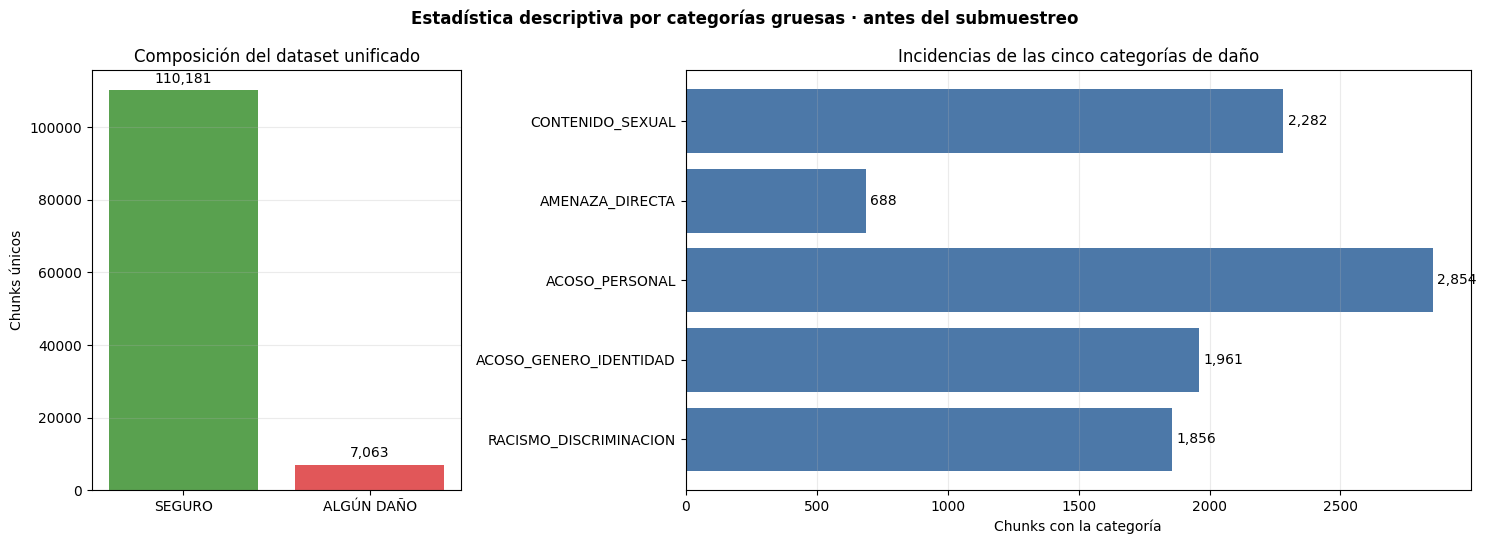

Figura guardada en: resultados\figuras\transformer_grueso\descriptiva_dataset_unificado_categorias_gruesas.png


In [4]:
integrated_frame = frames['integrated'].reset_index(drop=True)
text_words = integrated_frame['text'].fillna('').str.split().str.len()
descriptive_sample = pd.DataFrame({
    'indicador': [
        'Chunks utilizables únicos', 'Videos únicos', 'Chunks SEGURO',
        'Chunks con al menos un daño', 'Chunks con más de un daño',
        'Palabras por chunk: media', 'Palabras por chunk: mediana',
        'Palabras por chunk: P25', 'Palabras por chunk: P75'
    ],
    'valor': [
        len(integrated_frame), integrated_frame['video_id'].nunique(),
        integration['safe_rows'], integration['damage_unique_rows'],
        integration['multilabel_damage_rows'], round(text_words.mean(), 2),
        round(text_words.median(), 2), round(text_words.quantile(.25), 2),
        round(text_words.quantile(.75), 2)
    ]
})
display(descriptive_sample)

coarse_order = ['SEGURO', *tm.DAMAGE_ORDER]
integrated_counts = {
    'SEGURO': integration['safe_rows'],
    **integration['category_counts'],
}
def part_count(part, label):
    return audit['parts'][part]['safe_rows'] if label == 'SEGURO' else audit['parts'][part]['category_counts'][label]

category_table = pd.DataFrame({
    'categoría_gruesa': coarse_order,
    'n_dataset_integrado': [integrated_counts[label] for label in coarse_order],
    'pct_sobre_chunks_integrados': [100 * integrated_counts[label] / len(integrated_frame) for label in coarse_order],
    'n_muestra_4a1': [part_count('balanced_all', label) for label in coarse_order],
    'n_train': [part_count('train', label) for label in coarse_order],
    'n_validación': [part_count('validation', label) for label in coarse_order],
    'n_test': [part_count('test', label) for label in coarse_order],
})
category_table['pct_sobre_chunks_integrados'] = category_table['pct_sobre_chunks_integrados'].round(2)
display(category_table)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={'width_ratios': [0.8, 1.7]})
overview_labels = ['SEGURO', 'ALGÚN DAÑO']
overview_counts = [integration['safe_rows'], integration['damage_unique_rows']]
bars = axes[0].bar(overview_labels, overview_counts, color=['#59A14F', '#E15759'])
axes[0].bar_label(bars, fmt='{:,.0f}', padding=3)
axes[0].set_title('Composición del dataset unificado')
axes[0].set_ylabel('Chunks únicos')
axes[0].grid(axis='y', alpha=.25)
damage_counts = [integration['category_counts'][label] for label in tm.DAMAGE_ORDER]
bars = axes[1].barh(tm.DAMAGE_ORDER, damage_counts, color='#4C78A8')
axes[1].bar_label(bars, fmt='{:,.0f}', padding=3)
axes[1].set_title('Incidencias de las cinco categorías de daño')
axes[1].set_xlabel('Chunks con la categoría')
axes[1].grid(axis='x', alpha=.25)
fig.suptitle('Estadística descriptiva por categorías gruesas · antes del submuestreo', fontweight='bold')
tm.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
descriptive_figure = tm.FIGURES_DIR / 'descriptiva_dataset_unificado_categorias_gruesas.png'
plt.tight_layout(); plt.savefig(descriptive_figure, dpi=180, bbox_inches='tight'); plt.show()
print('Figura guardada en:', descriptive_figure.relative_to(ROOT))

## 2. Modelos clásicos: control rápido antes de los Transformers

Primero se ejecuta un *screening* rápido con las configuraciones ya fijadas: Dummy prior, Complement NB (`alpha=0.5`), regresión logística (`C=1`), SVM lineal palabra+carácter (`C=1`) y gradient boosting + SVD. Todos usan el train vigente derivado del dataset 4:1 seleccionado en las primeras celdas, texto sin contexto concatenado, 50.000 features cuando corresponde y peso Flash 0,50. Esta etapa usa validación para elegir tres familias candidatas y **no consulta test**.

`PLN_clases/clase4/Cuadernos/nlp_sesion4_1_FastText_Intro.ipynb` contiene otro clasificador supervisado aplicable: fastText. Se agrega como sexto modelo con la receta multietiqueta OVA publicada por fastText (`lr=0.5`, 25 épocas, bigramas, dimensión 50). Word2Vec es una representación y K-Means un agrupador no supervisado, por lo que no sustituyen aquí a un clasificador comparable. La selección se hace por PR-AUC macro de daño en validación; el test no escoge el ganador (Joulin et al., 2017; Cawley & Talbot, 2010).

In [5]:
display(pd.DataFrame([
    {'modelo': tm.CLASSICAL_MODEL_LABELS[key], **tm.PRIOR_CLASSICAL_CONFIGS[key]}
    for key in tm.CLASSICAL_MODEL_ORDER
]))

classical_screening = tm.run_classical_benchmarks(frames, validation_only=True)
print('Screening clásico completo: 6/6 modelos; test todavía cerrado.')
print('Resultados:', tm.METRICS_DIR.relative_to(ROOT) / 'screening_modelos_clasicos.csv')

,modelo,alpha,C,lr,epoch,wordNgrams,bucket,dim,loss
0,Dummy (prior),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Complement NB,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Regresión logística,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
3,SVM lineal palabra+carácter,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
4,Gradient boosting + SVD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,fastText supervisado OVA (sesión 4),NaN,NaN,0.5,25.0,2.0,200000.0,50.0,ova


Modelos clásicos:   0%|          | 0/6 [00:00<?, ?modelo/s]

Screening clásico completo: 6/6 modelos; test todavía cerrado.
Resultados: resultados\metricas\transformer_grueso\screening_modelos_clasicos.csv


### 2.1 Comparación inicial y selección de tres familias

Esta celda se ejecuta **después de terminar los seis clásicos y antes de iniciar cualquier Transformer**. Ordena exclusivamente por PR-AUC macro de daño en validación y conserva las tres mejores familias no triviales para la búsqueda de hiperparámetros. Test permanece sin consultar; Dummy sirve únicamente como control negativo.

,model_label,train_rows,training_seconds,validation_damage_pr_auc_macro,validation_damage_f1_macro
0,SVM lineal palabra+carácter,24701,39.0911,0.4414,0.4711
1,Regresión logística,24701,6.8971,0.4195,0.4628
2,fastText supervisado OVA (sesión 4),24701,4.8784,0.3375,0.3772
3,Complement NB,24701,1.8475,0.2019,0.2528
4,Gradient boosting + SVD,24701,9.3186,0.1959,0.2846
5,Dummy (prior),24701,0.0055,0.0556,0.0973


**Familias que pasan a la búsqueda:** SVM lineal palabra+carácter, Regresión logística, fastText supervisado OVA (sesión 4)

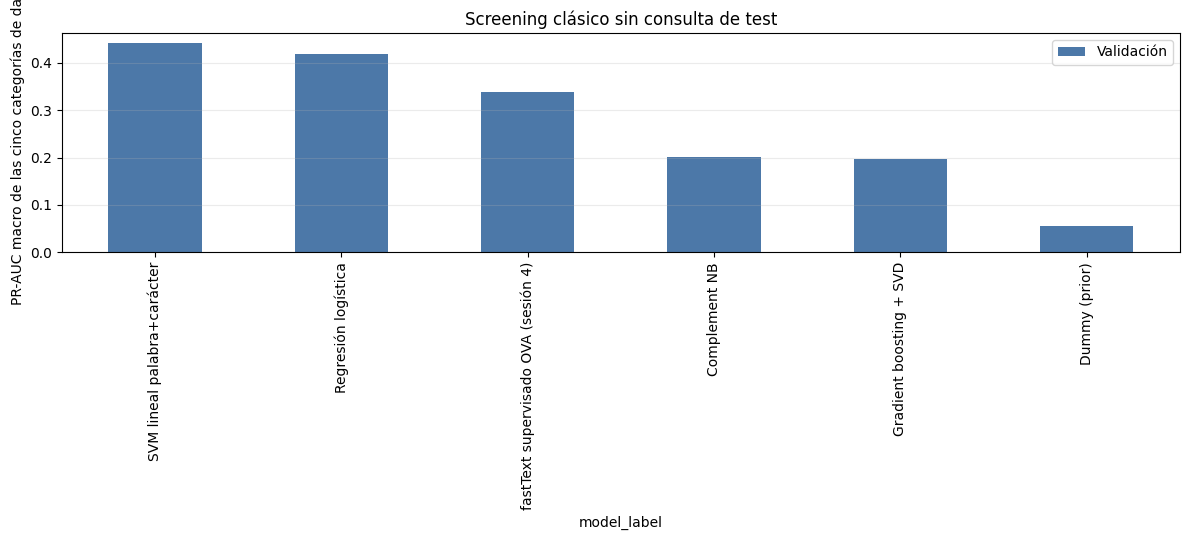

Figura: resultados\figuras\transformer_grueso\screening_modelos_clasicos_validacion.png
Test evaluado: False


In [6]:
classic_results = pd.DataFrame(classical_screening['comparison'])
full_classic_results = (
    classic_results
    .sort_values(['validation_damage_pr_auc_macro', 'validation_damage_f1_macro'], ascending=False)
    .reset_index(drop=True)
)
comparison_columns = [
    'model_label', 'train_rows', 'training_seconds',
    'validation_damage_pr_auc_macro', 'validation_damage_f1_macro'
]
display(full_classic_results[comparison_columns].style.format({
    column: '{:.4f}' for column in comparison_columns if column not in ('model_label', 'train_rows')
}))

top_three = classical_screening['top_candidates']
display(Markdown('**Familias que pasan a la búsqueda:** ' + ', '.join(
    tm.CLASSICAL_MODEL_LABELS[name] for name in top_three
)))

plot_frame = full_classic_results.set_index('model_label')[
    ['validation_damage_pr_auc_macro']
].rename(columns={'validation_damage_pr_auc_macro': 'Validación'})
ax = plot_frame.plot.bar(figsize=(12, 5.5), color=['#4C78A8'])
ax.set_ylabel('PR-AUC macro de las cinco categorías de daño')
ax.set_title('Screening clásico sin consulta de test')
ax.grid(axis='y', alpha=.25)
ax.legend(loc='best')
plt.tight_layout()
classic_figure = tm.FIGURES_DIR / 'screening_modelos_clasicos_validacion.png'
plt.savefig(classic_figure, dpi=180, bbox_inches='tight')
plt.show()
print('Figura:', classic_figure.relative_to(ROOT))
print('Test evaluado:', classical_screening['test_evaluated'])

### 2.2 Búsqueda acotada de hiperparámetros para los tres mejores clásicos

Las tres familias no triviales con mayor PR-AUC macro de daño en el *screening* se optimizan mediante `GroupKFold` de tres particiones dentro de `train`, agrupando por `video_id`. Ningún video puede aparecer simultáneamente en ajuste y evaluación interna. Se prueban ocho configuraciones declaradas de antemano por familia; la combinación ganadora minimiza primero el error de ranking mediante la media de PR-AUC macro y usa su desviación entre folds como desempate.

Después de la búsqueda, cada familia se reentrena con todo `train`; los umbrales por categoría se calibran exclusivamente en validación. El mejor clásico se congela por PR-AUC macro de validación y **solo entonces** se consulta test. Así la búsqueda de hiperparámetros no adapta decisiones al conjunto de prueba y la comparación posterior con Transformers utiliza una línea base clásica optimizada (Cawley & Talbot, 2010). La barra informa modelo, configuración, fold, métrica y tiempo; esta celda puede tardar aproximadamente 30–90 minutos en CPU.

,modelo,configuraciones,folds_por_configuración,ajustes_CV
0,SVM lineal palabra+carácter,8,3,24
1,Regresión logística,8,3,24
2,fastText supervisado OVA (sesión 4),8,3,24


Total de ajustes CV: 72
Test permanece cerrado durante estos ajustes.


  0%|          | 0/75 [00:00<?, ?ajuste/s]

,model_label,parameters,mean_cv_damage_pr_auc_macro,std_cv_damage_pr_auc_macro,cv_training_seconds
0,fastText supervisado OVA (sesión 4),"{'lr': 0.5, 'epoch': 15, 'wordNgrams': 2, 'bucket': 200000, 'dim': 50, 'loss': 'ova'}",0.2902,0.0129,11.6
1,SVM lineal palabra+carácter,"{'C': 0.25, 'min_df': 1, 'max_features': 50000}",0.4074,0.0108,68.4
2,Regresión logística,"{'C': 2.0, 'min_df': 2, 'max_features': 50000}",0.3818,0.0156,17.2


,model_label,best_parameters,mean_cv_damage_pr_auc_macro,validation_damage_pr_auc_macro,validation_damage_f1_macro,test_damage_pr_auc_macro,test_damage_f1_macro,test_damage_recall_micro
0,SVM lineal palabra+carácter,"{'C': 0.25, 'min_df': 1, 'max_features': 50000}",0.4074,0.4612,0.4882,0.4174,0.4517,0.4850
1,Regresión logística,"{'C': 2.0, 'min_df': 2, 'max_features': 50000}",0.3818,0.4292,0.4696,0.3994,0.4159,0.4700
2,fastText supervisado OVA (sesión 4),"{'lr': 0.5, 'epoch': 15, 'wordNgrams': 2, 'bucket': 200000, 'dim': 50, 'loss': 'ova'}",0.2902,0.3419,0.3812,0.3240,0.3444,0.3400


**Clásico optimizado y congelado:** SVM lineal palabra+carácter  Parámetros: `{'C': 0.25, 'min_df': 1, 'max_features': 50000}`  PR-AUC macro de daño: validación `0.4612`; test `0.4174`.

**Resultados por categoría del clásico congelado en test:**

,precision,recall,f1-score,support
SEGURO,0.905475,0.867969,0.886325,4249.0
RACISMO_DISCRIMINACION,0.469314,0.507812,0.487805,256.0
ACOSO_GENERO_IDENTIDAD,0.422939,0.448669,0.435424,263.0
ACOSO_PERSONAL,0.345745,0.448276,0.390390,435.0
AMENAZA_DIRECTA,0.382979,0.324324,0.351220,111.0
CONTENIDO_SEXUAL,0.589971,0.597015,0.593472,335.0
micro avg,0.776218,0.773057,0.774634,5649.0
macro avg,0.519404,0.532344,0.524106,5649.0
weighted avg,0.791165,0.773057,0.781202,5649.0
samples avg,0.796125,0.796692,0.792715,5649.0


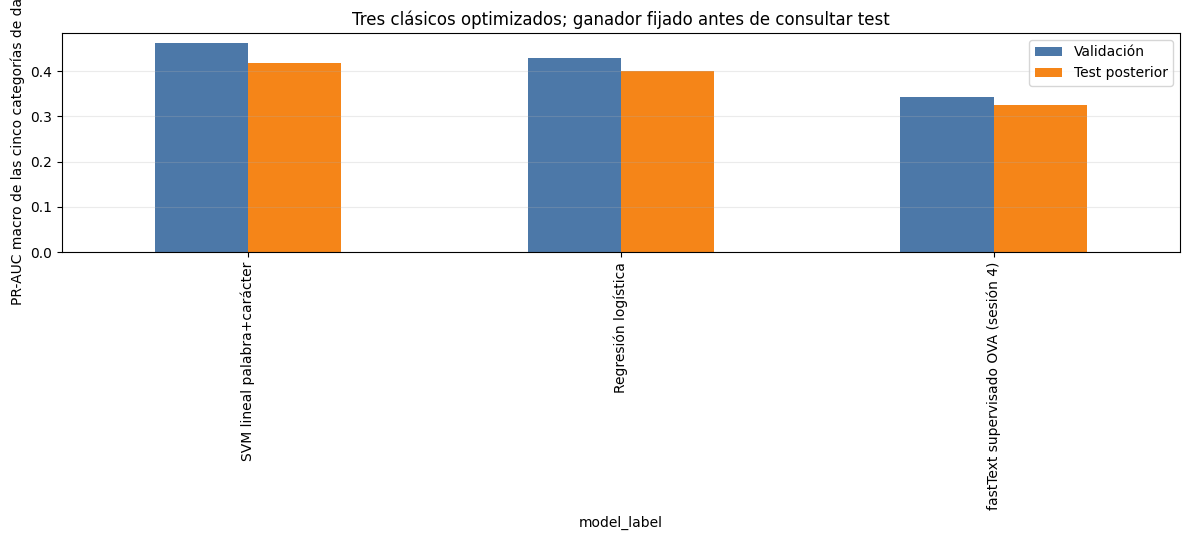

Figura: resultados\figuras\transformer_grueso\comparacion_clasicos_optimizados.png


**Línea base clásica optimizada para comparar los Transformers:**

,modelo,model_key,PR-AUC daño validación,PR-AUC daño test,precisión autónoma test,recall autónomo test,recall mínimo categoría,F1 macro daño test,puerta desempeño autónomo,autonomía autorizada,tasa revisión humana,recall alerta test,límite inferior recall 95%,VPN auto-paso,daños no alertados,alerta humana respaldada,modo recomendado
0,SVM lineal palabra+carácter,classical__linear_svm_word_char,0.461198,0.417355,0.53903,0.630163,0.324324,0.451662,False,False,0.637618,0.951969,0.937236,0.973918,50,False,research_only


,escenario,precisión,recall,VPN,proporción enviada a revisión,falsos negativos
0,Decisión autónoma,0.539030,0.630163,0.905475,0.230057,385
1,Alerta humana calibrada en validación,0.296757,0.950835,0.971658,0.648760,53
2,Alerta humana en test,0.293804,0.951969,0.973918,0.637618,50


,categoría,recall autónomo test
0,RACISMO_DISCRIMINACION,0.507812
1,ACOSO_GENERO_IDENTIDAD,0.448669
2,ACOSO_PERSONAL,0.448276
3,AMENAZA_DIRECTA,0.324324
4,CONTENIDO_SEXUAL,0.597015


**Conclusión provisional para SVM lineal palabra+carácter:** No alcanza la puerta mínima para uso operativo.

In [7]:
search_plan = pd.DataFrame([
    {
        'modelo': tm.CLASSICAL_MODEL_LABELS[name],
        'configuraciones': len(tm.CLASSICAL_TUNING_GRIDS[name]),
        'folds_por_configuración': tm.CLASSICAL_TUNING_FOLDS,
        'ajustes_CV': len(tm.CLASSICAL_TUNING_GRIDS[name]) * tm.CLASSICAL_TUNING_FOLDS,
    }
    for name in classical_screening['top_candidates']
])
display(search_plan)
print('Total de ajustes CV:', search_plan['ajustes_CV'].sum())
print('Test permanece cerrado durante estos ajustes.')

classical = tm.tune_top_classical_models(frames, classical_screening)

cv_results = pd.DataFrame(classical['cv_results'])
best_cv = (
    cv_results
    .sort_values(['model', 'mean_cv_damage_pr_auc_macro', 'std_cv_damage_pr_auc_macro'],
                 ascending=[True, False, True])
    .groupby('model', as_index=False)
    .first()
)
display(best_cv[[
    'model_label', 'parameters', 'mean_cv_damage_pr_auc_macro',
    'std_cv_damage_pr_auc_macro', 'cv_training_seconds'
]].style.format({
    'mean_cv_damage_pr_auc_macro': '{:.4f}',
    'std_cv_damage_pr_auc_macro': '{:.4f}',
    'cv_training_seconds': '{:.1f}',
}))

optimized_results = (
    pd.DataFrame(classical['comparison'])
    .sort_values(['validation_damage_pr_auc_macro', 'validation_damage_f1_macro'],
                 ascending=False)
    .reset_index(drop=True)
)
optimized_columns = [
    'model_label', 'best_parameters', 'mean_cv_damage_pr_auc_macro',
    'validation_damage_pr_auc_macro', 'validation_damage_f1_macro',
    'test_damage_pr_auc_macro', 'test_damage_f1_macro', 'test_damage_recall_micro'
]
display(optimized_results[optimized_columns].style.format({
    column: '{:.4f}' for column in optimized_columns
    if column not in ('model_label', 'best_parameters')
}))

winner_row = optimized_results.loc[
    optimized_results['experiment_id'].eq(classical['winner_id'])
].iloc[0]
display(Markdown(
    f"**Clásico optimizado y congelado:** {classical['winner_label']}  \
"
    f"Parámetros: `{classical['winner_parameters']}`  \
"
    f"PR-AUC macro de daño: validación `{winner_row['validation_damage_pr_auc_macro']:.4f}`; "
    f"test `{winner_row['test_damage_pr_auc_macro']:.4f}`."
))

winner_report = tm.METRICS_DIR / f"reporte_test_ajustado_{classical['winner_model']}.csv"
display(Markdown('**Resultados por categoría del clásico congelado en test:**'))
display(pd.read_csv(winner_report, index_col=0))

plot_frame = optimized_results.set_index('model_label')[[
    'validation_damage_pr_auc_macro', 'test_damage_pr_auc_macro'
]].rename(columns={
    'validation_damage_pr_auc_macro': 'Validación',
    'test_damage_pr_auc_macro': 'Test posterior',
})
ax = plot_frame.plot.bar(figsize=(12, 5.5), color=['#4C78A8', '#F58518'])
ax.set_ylabel('PR-AUC macro de las cinco categorías de daño')
ax.set_title('Tres clásicos optimizados; ganador fijado antes de consultar test')
ax.grid(axis='y', alpha=.25)
ax.legend(loc='best')
plt.tight_layout()
classic_figure = tm.FIGURES_DIR / 'comparacion_clasicos_optimizados.png'
plt.savefig(classic_figure, dpi=180, bbox_inches='tight')
plt.show()
print('Figura:', classic_figure.relative_to(ROOT))

analysis_classical = tm.analyze_classical_winner(classical, frames)
display(Markdown('**Línea base clásica optimizada para comparar los Transformers:**'))
mostrar_analisis_operativo(analysis_classical)

## 3. Selección del balanceo con encoder congelado

El tamaño vigente del entrenamiento se obtiene de la auditoría después de la partición por video. Dentro de esa muestra, cada encoder compara BCE normal con ponderación positiva moderada `sqrt(N_neg/N_pos)`. La selección usa sólo PR-AUC macro de daño en validación. El encoder congelado permite escoger la pérdida con bajo coste antes del fine-tuning.

El remuestreo y reponderado son habituales ante colas largas, pero pueden alterar dependencias multietiqueta; por ello se validan empíricamente (Huang et al., 2021).

In [8]:
screenings = {}
for key, spec in tm.MODEL_SPECS.items():
    print(f'\n=== Linear probe: {spec.label} ===')
    screenings[key] = tm.run_linear_screening(spec, frames)
    display(pd.DataFrame(screenings[key]['comparison'])[[
        'mode', 'damage_pr_auc_macro', 'damage_f1_macro',
        'damage_recall_micro', 'any_damage_precision', 'any_damage_recall'
    ]])


=== Linear probe: Paraphrase Multilingual MiniLM-L12 ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/772 [00:00<?, ?it/s]

Batches:   0%|          | 0/167 [00:00<?, ?it/s]

,mode,damage_pr_auc_macro,damage_f1_macro,damage_recall_micro,any_damage_precision,any_damage_recall
0,sqrt_positive_weight,0.379996,0.418574,0.478026,0.453741,0.618738
1,plain_bce,0.374520,0.414932,0.523327,0.418592,0.689239


...

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Batches:   0%|          | 0/772 [00:00<?, ?it/s]

Batches:   0%|          | 0/167 [00:00<?, ?it/s]

,mode,damage_pr_auc_macro,damage_f1_macro,damage_recall_micro,any_damage_precision,any_damage_recall
0,sqrt_positive_weight,0.423859,0.453365,0.518594,0.489694,0.639147
1,plain_bce,0.416214,0.443800,0.517241,0.468605,0.657699


## 4. Fine-tuning completo de Paraphrase MiniLM

Se actualizan todas las capas del encoder y la cabeza de cinco sigmoidales. AdamW usa `learning_rate=2e-5`, longitud 128, batch 8, máximo tres épocas y parada temprana con paciencia 1. La barra informa pérdida y ETA. En CPU, espere aproximadamente 20–30 minutos por época; el tiempo real aparecerá en la barra.

In [9]:
training_minilm = tm.run_finetuning(tm.MODEL_SPECS['paraphrase_minilm'], frames)
display(pd.DataFrame(training_minilm['history'])[[
    'epoch', 'training_loss', 'damage_pr_auc_macro',
    'damage_f1_macro', 'damage_recall_micro', 'epoch_seconds'
]])
print('Mejor época:', training_minilm['best_epoch'])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

paraphrase_minilm · época 1/3:   0%|          | 0/3088 [00:00<?, ?lote/s]

paraphrase_minilm · validación época 1:   0%|          | 0/167 [00:00<?, ?lote/s]

Paraphrase Multilingual MiniLM-L12 · época 1: loss=0.5945, PR-AUC val=0.4592, F1 macro val=0.4817, recall daño=0.5091, tiempo=46.7 min


paraphrase_minilm · época 2/3:   0%|          | 0/3088 [00:00<?, ?lote/s]

...

paraphrase_minilm · época 3/3:   0%|          | 0/3088 [00:00<?, ?lote/s]

paraphrase_minilm · validación época 3:   0%|          | 0/167 [00:00<?, ?lote/s]

Paraphrase Multilingual MiniLM-L12 · época 3: loss=0.3459, PR-AUC val=0.5017, F1 macro val=0.5261, recall daño=0.5456, tiempo=43.6 min


,epoch,training_loss,damage_pr_auc_macro,damage_f1_macro,damage_recall_micro,epoch_seconds
0,1,0.594516,0.459231,0.481746,0.509128,2803.387496
1,2,0.440080,0.502351,0.523048,0.524679,2548.857886
2,3,0.345873,0.501747,0.526086,0.545639,2616.794995


Mejor época: 2


### 4.1 Puerta operativa de MiniLM antes de entrenar E5

Esta celda evalúa el mejor checkpoint de MiniLM y lo compara con el clásico ganador. Para autonomía se examinan precisión, recall, límite Wilson 95 %, F1 macro y el peor recall entre categorías. Para asistencia humana se calibra **sólo en validación** el umbral de riesgo que captura al menos 95 % del daño y se traslada sin cambios al test; se reportan recall, VPN, falsos negativos y carga de revisión.

La filosofía sigue la clasificación selectiva o *reject option*: reducir riesgo absteniéndose y enviando observaciones a revisión (Geifman & El-Yaniv, 2017). En moderación, la variable operativa central es el intercambio entre recall y proporción que debe revisar una persona (Tonneau et al., 2024). La arquitectura y los hiperparámetros de E5 ya están fijados en el módulo; no deben modificarse después de mirar este test.

In [10]:
evaluation_minilm = tm.evaluate_finetuned_model(
    tm.MODEL_SPECS['paraphrase_minilm'], frames
)
analysis_minilm = tm.analyze_transformer_operational(
    tm.MODEL_SPECS['paraphrase_minilm'], frames, evaluation_minilm
)
mostrar_analisis_operativo(analysis_minilm, [analysis_classical])
print('Esta evaluación terminó. Ahora puede decidir si continúa con E5.')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

paraphrase_minilm · validation:   0%|          | 0/167 [00:00<?, ?lote/s]

paraphrase_minilm · test:   0%|          | 0/166 [00:00<?, ?lote/s]

,modelo,model_key,PR-AUC daño validación,PR-AUC daño test,precisión autónoma test,recall autónomo test,recall mínimo categoría,F1 macro daño test,puerta desempeño autónomo,autonomía autorizada,tasa revisión humana,recall alerta test,límite inferior recall 95%,VPN auto-paso,daños no alertados,alerta humana respaldada,modo recomendado
1,Paraphrase Multilingual MiniLM-L12,paraphrase_minilm,0.502351,0.457578,0.579221,0.642651,0.207207,0.460005,False,False,0.717958,0.953890,0.939396,0.967828,48,False,research_only
0,SVM lineal palabra+carácter,classical__linear_svm_word_char,0.461198,0.417355,0.539030,0.630163,0.324324,0.451662,False,False,0.637618,0.951969,0.937236,0.973918,50,False,research_only


,escenario,precisión,recall,VPN,proporción enviada a revisión,falsos negativos
0,Decisión autónoma,0.579221,0.642651,0.910036,0.218336,372
1,Alerta humana calibrada en validación,0.271955,0.950835,0.965916,0.707926,53
2,Alerta humana en test,0.261453,0.953890,0.967828,0.717958,48


,categoría,recall autónomo test
0,RACISMO_DISCRIMINACION,0.527344
1,ACOSO_GENERO_IDENTIDAD,0.547529
2,ACOSO_PERSONAL,0.485057
3,AMENAZA_DIRECTA,0.207207
4,CONTENIDO_SEXUAL,0.555224


**Conclusión provisional para Paraphrase Multilingual MiniLM-L12:** No alcanza la puerta mínima para uso operativo.

Esta evaluación terminó. Ahora puede decidir si continúa con E5.


## 5. Fine-tuning completo de Multilingual E5-small

E5-small deriva de Multilingual MiniLM-L12-H384 y mantiene un coste semejante. Su preentrenamiento contrastivo multilingüe más amplio constituye una expectativa razonable de mejora, no una garantía (Wang et al., 2024). Para una comparación limpia también usa 128 tokens; una ablación posterior podrá probar 256.

In [11]:
training_e5 = tm.run_finetuning(tm.MODEL_SPECS['e5_small'], frames)
display(pd.DataFrame(training_e5['history'])[[
    'epoch', 'training_loss', 'damage_pr_auc_macro',
    'damage_f1_macro', 'damage_recall_micro', 'epoch_seconds'
]])
print('Mejor época:', training_e5['best_epoch'])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

e5_small · época 1/3:   0%|          | 0/3088 [00:00<?, ?lote/s]

e5_small · validación época 1:   0%|          | 0/167 [00:00<?, ?lote/s]

Multilingual E5-small (linaje MiniLM) · época 1: loss=0.6261, PR-AUC val=0.4299, F1 macro val=0.4565, recall daño=0.5051, tiempo=36.4 min


e5_small · época 2/3:   0%|          | 0/3088 [00:00<?, ?lote/s]

...

e5_small · época 3/3:   0%|          | 0/3088 [00:00<?, ?lote/s]

e5_small · validación época 3:   0%|          | 0/167 [00:00<?, ?lote/s]

Multilingual E5-small (linaje MiniLM) · época 3: loss=0.4045, PR-AUC val=0.5082, F1 macro val=0.5251, recall daño=0.5193, tiempo=47.1 min


,epoch,training_loss,damage_pr_auc_macro,damage_f1_macro,damage_recall_micro,epoch_seconds
0,1,0.626108,0.429867,0.456498,0.505071,2183.533571
1,2,0.475385,0.487633,0.509736,0.505071,2415.163874
2,3,0.404550,0.508154,0.525126,0.519270,2827.298735


Mejor época: 3


### 5.1 Puerta operativa de E5 antes de la comparación final

Se repite exactamente la puerta aplicada a MiniLM: umbrales de decisión y enrutamiento se fijan en validación y se trasladan sin cambios al test. La comparación provisional incluye el clásico ganador, MiniLM y E5.

In [12]:
evaluation_e5 = tm.evaluate_finetuned_model(tm.MODEL_SPECS['e5_small'], frames)
analysis_e5 = tm.analyze_transformer_operational(
    tm.MODEL_SPECS['e5_small'], frames, evaluation_e5
)
mostrar_analisis_operativo(
    analysis_e5, [analysis_classical, analysis_minilm]
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

e5_small · validation:   0%|          | 0/167 [00:00<?, ?lote/s]

e5_small · test:   0%|          | 0/166 [00:00<?, ?lote/s]

,modelo,model_key,PR-AUC daño validación,PR-AUC daño test,precisión autónoma test,recall autónomo test,recall mínimo categoría,F1 macro daño test,puerta desempeño autónomo,autonomía autorizada,tasa revisión humana,recall alerta test,límite inferior recall 95%,VPN auto-paso,daños no alertados,alerta humana respaldada,modo recomendado
2,Multilingual E5-small (linaje MiniLM),e5_small,0.508154,0.439886,0.596934,0.635927,0.279279,0.472997,False,False,0.653686,0.943324,0.927579,0.967795,59,False,research_only
1,Paraphrase Multilingual MiniLM-L12,paraphrase_minilm,0.502351,0.457578,0.579221,0.642651,0.207207,0.460005,False,False,0.717958,0.953890,0.939396,0.967828,48,False,research_only
0,SVM lineal palabra+carácter,classical__linear_svm_word_char,0.461198,0.417355,0.539030,0.630163,0.324324,0.451662,False,False,0.637618,0.951969,0.937236,0.973918,50,False,research_only


,escenario,precisión,recall,VPN,proporción enviada a revisión,falsos negativos
0,Decisión autónoma,0.596934,0.635927,0.909352,0.209641,379
1,Alerta humana calibrada en validación,0.298052,0.950835,0.971883,0.645943,53
2,Alerta humana en test,0.283979,0.943324,0.967795,0.653686,59


,categoría,recall autónomo test
0,RACISMO_DISCRIMINACION,0.585938
1,ACOSO_GENERO_IDENTIDAD,0.501901
2,ACOSO_PERSONAL,0.459770
3,AMENAZA_DIRECTA,0.279279
4,CONTENIDO_SEXUAL,0.602985


**Conclusión provisional para Multilingual E5-small (linaje MiniLM):** No alcanza la puerta mínima para uso operativo.

## 6. Comparación final y filosofía de producción

La jerarquía se declara antes de elegir: (1) sólo un modelo que supere desempeño **y** evidencia externa podría ser autónomo; (2) si ninguno lo logra, se considera un piloto de alerta humana; (3) si tampoco supera esa puerta, queda restringido a investigación. Entre candidatos del mismo nivel se elige por PR-AUC de validación; el test funciona como puerta de aceptación, no como métrica de ranking. Después se realiza el bootstrap pareado por video frente al mejor clásico (Cawley & Talbot, 2010).

,modelo,model_key,PR-AUC daño validación,PR-AUC daño test,precisión autónoma test,recall autónomo test,recall mínimo categoría,F1 macro daño test,puerta desempeño autónomo,autonomía autorizada,tasa revisión humana,recall alerta test,límite inferior recall 95%,VPN auto-paso,daños no alertados,alerta humana respaldada,modo recomendado
2,Multilingual E5-small (linaje MiniLM),e5_small,0.508154,0.439886,0.596934,0.635927,0.279279,0.472997,False,False,0.653686,0.943324,0.927579,0.967795,59,False,research_only
1,Paraphrase Multilingual MiniLM-L12,paraphrase_minilm,0.502351,0.457578,0.579221,0.642651,0.207207,0.460005,False,False,0.717958,0.953890,0.939396,0.967828,48,False,research_only
0,SVM lineal palabra+carácter,classical__linear_svm_word_char,0.461198,0.417355,0.539030,0.630163,0.324324,0.451662,False,False,0.637618,0.951969,0.937236,0.973918,50,False,research_only


### Decisión

**Modelo:** ninguno  **Modo:** `none`  **Estado:** `no_model_is_ready_for_production`  **Autonomía respaldada:** False  **Alerta humana respaldada:** False

Transformer ganador por validación: Multilingual E5-small (linaje MiniLM)


Bootstrap pareado por video:   0%|          | 0/1000 [00:00<?, ?réplica/s]

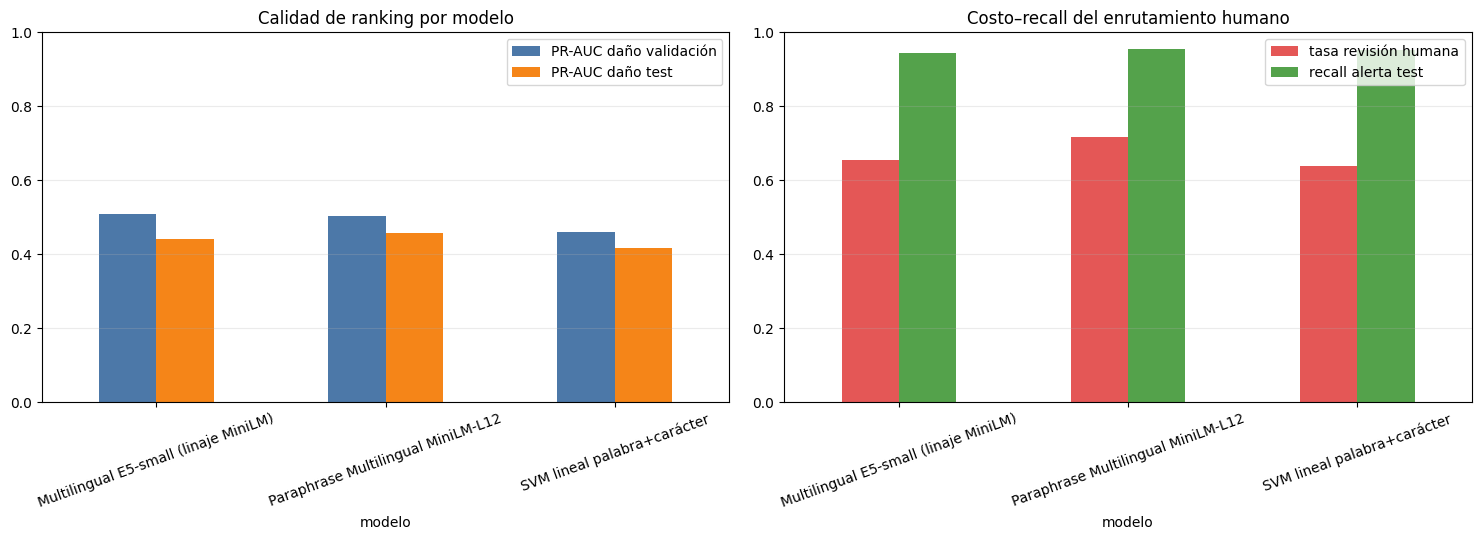

Informe técnico: resultados\INFORME_ENTRENAMIENTO_TRANSFORMER_GRUESO.md
Informe operativo: resultados\INFORME_DECISION_OPERATIVA_MODERADOR.md
Registro para 04_3: modelos\moderador_transformer_grueso\registro_modelos_comparables.json


In [13]:
trainings = {'paraphrase_minilm': training_minilm, 'e5_small': training_e5}
evaluations = {
    'paraphrase_minilm': evaluation_minilm,
    'e5_small': evaluation_e5,
}
operational_analyses = [analysis_classical, analysis_minilm, analysis_e5]
final_comparison = tm.operational_comparison_frame(operational_analyses)
display(final_comparison)
production_selection = tm.select_production_candidate(operational_analyses)
display(Markdown(
    f"### Decisión\n\n**Modelo:** {production_selection.get('selected_model_label') or 'ninguno'}  \
"
    f"**Modo:** `{production_selection['operating_mode']}`  \
"
    f"**Estado:** `{production_selection['status']}`  \
"
    f"**Autonomía respaldada:** {production_selection['autonomous_deployment_supported']}  \
"
    f"**Alerta humana respaldada:** {production_selection['human_review_alert_supported']}"
))

winner_key = max(
    tm.MODEL_SPECS,
    key=lambda key: (
        evaluations[key]['metrics']['validation']['damage_pr_auc_macro'],
        evaluations[key]['metrics']['validation']['damage_f1_macro'],
    ),
)
print('Transformer ganador por validación:', tm.MODEL_SPECS[winner_key].label)
bootstrap = tm.paired_video_bootstrap(tm.MODEL_SPECS[winner_key], frames)
tm.create_figures(audit, evaluations, trainings, classical)
tm.write_report(audit, trainings, evaluations, classical, bootstrap, winner_key)
tm.write_operational_decision_report(operational_analyses, production_selection)
model_registry = tm.write_model_registry(
    classical, trainings, evaluations, production_selection
)

plot_operational = final_comparison.set_index('modelo')[[
    'PR-AUC daño validación', 'PR-AUC daño test',
    'tasa revisión humana', 'recall alerta test'
]]
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
plot_operational[['PR-AUC daño validación', 'PR-AUC daño test']].plot.bar(
    ax=axes[0], color=['#4C78A8', '#F58518']
)
plot_operational[['tasa revisión humana', 'recall alerta test']].plot.bar(
    ax=axes[1], color=['#E45756', '#54A24B']
)
axes[0].set_title('Calidad de ranking por modelo')
axes[1].set_title('Costo–recall del enrutamiento humano')
for ax in axes:
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=.25)
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
operational_figure = tm.FIGURES_DIR / 'comparacion_operativa_todos_modelos_04_2.png'
plt.savefig(operational_figure, dpi=180, bbox_inches='tight')
plt.show()
print('Informe técnico:', tm.REPORT_PATH.relative_to(ROOT))
print('Informe operativo:', tm.OPERATIONAL_REPORT_PATH.relative_to(ROOT))
print('Registro para 04_3:', tm.MODEL_REGISTRY_PATH.relative_to(ROOT))

In [14]:
result_rows = []
for key, result in evaluations.items():
    for split in ('validation', 'test'):
        metrics = result['metrics'][split]
        result_rows.append({
            'modelo': tm.MODEL_SPECS[key].label, 'partición': split,
            'PR-AUC macro daño': metrics['damage_pr_auc_macro'],
            'F1 macro daño': metrics['damage_f1_macro'],
            'recall micro daño': metrics['damage_recall_micro'],
            'precisión algún daño': metrics['any_damage_precision'],
            'recall algún daño': metrics['any_damage_recall'],
            'daños omitidos como seguros': metrics['missed_damage_as_safe'],
        })
display(pd.DataFrame(result_rows))
display(pd.DataFrame(bootstrap['metrics']).T)

,modelo,partición,PR-AUC macro daño,F1 macro daño,recall micro daño,precisión algún daño,recall algún daño,daños omitidos como seguros
0,Paraphrase Multilingual MiniLM-L12,validation,0.502351,0.523048,0.524679,0.598639,0.653061,374
1,Paraphrase Multilingual MiniLM-L12,test,0.457578,0.460005,0.499286,0.579221,0.642651,372
2,Multilingual E5-small (linaje MiniLM),validation,0.508154,0.525126,0.519270,0.653668,0.653061,374
3,Multilingual E5-small (linaje MiniLM),test,0.439886,0.472997,0.510714,0.596934,0.635927,379


,mean_difference,ci_95_percentile,probability_difference_gt_zero
damage_pr_auc_macro,0.021785,"[-0.010213701028467784, 0.05456722684677204]",0.9
damage_f1_macro,0.04996,"[0.02130126987581542, 0.0780092692308792]",1.0
damage_recall_micro,-0.109428,"[-0.14191449014561117, -0.07541023054660043]",0.0


![Balance y comparación](../resultados/figuras/transformer_grueso/balance_y_comparacion_transformers.png)

![Curvas de validación](../resultados/figuras/transformer_grueso/curvas_validacion_transformers.png)

![Comparación operativa](../resultados/figuras/transformer_grueso/comparacion_operativa_todos_modelos_04_2.png)

## 7. Informe externo

La comparación final genera `resultados/INFORME_ENTRENAMIENTO_TRANSFORMER_GRUESO.md`, `resultados/INFORME_DECISION_OPERATIVA_MODERADOR.md` y `modelos/moderador_transformer_grueso/registro_modelos_comparables.json`. Este último permite que `04_3_finetuning_qwen3_lora.ipynb` verifique y compare los modelos guardados sin repetir el `04_2`.

## Referencias (APA 7)

Cawley, G. C., & Talbot, N. L. C. (2010). On over-fitting in model selection and subsequent selection bias in performance evaluation. *Journal of Machine Learning Research, 11*, 2079–2107. https://www.jmlr.org/papers/v11/cawley10a.html

Huang, Y., Giledereli, B., Köksal, A., Özgür, A., & Ozkirimli, E. (2021). Balancing methods for multi-label text classification with long-tailed class distribution. In *Proceedings of the 2021 Conference on Empirical Methods in Natural Language Processing* (pp. 8153–8161). Association for Computational Linguistics. https://doi.org/10.18653/v1/2021.emnlp-main.643

Geifman, Y., & El-Yaniv, R. (2017). Selective classification for deep neural networks. In *Advances in Neural Information Processing Systems* (Vol. 30). https://proceedings.neurips.cc/paper/2017/hash/4a8423d5e91fda00bb7e46540e2b0cf1-Abstract.html

Joulin, A., Grave, E., Bojanowski, P., & Mikolov, T. (2017). Bag of tricks for efficient text classification. In *Proceedings of the 15th Conference of the European Chapter of the Association for Computational Linguistics: Volume 2, Short Papers* (pp. 427–431). Association for Computational Linguistics. https://aclanthology.org/E17-2068/

Reimers, N., & Gurevych, I. (2019). Sentence-BERT: Sentence embeddings using Siamese BERT-networks. In *Proceedings of EMNLP-IJCNLP 2019* (pp. 3982–3992). Association for Computational Linguistics. https://doi.org/10.18653/v1/D19-1410

Tonneau, M., Quinta de Castro, P. V., Lasri, K., Farouq, I., Subramanian, L., Orozco-Olvera, V., & Fraiberger, S. P. (2024). NAIJAHATE: Evaluating hate speech detection on Nigerian Twitter using representative data. In *Proceedings of the 62nd Annual Meeting of the Association for Computational Linguistics (Volume 1: Long Papers)* (pp. 9020–9040). Association for Computational Linguistics. https://aclanthology.org/2024.acl-long.488/

Wang, L., Yang, N., Huang, X., Yang, L., Majumder, R., & Wei, F. (2024). Multilingual E5 text embeddings: A technical report. *arXiv*. https://doi.org/10.48550/arXiv.2402.05672

Wang, W., Wei, F., Dong, L., Bao, H., Yang, N., & Zhou, M. (2020). MiniLM: Deep self-attention distillation for task-agnostic compression of pre-trained Transformers. In *Advances in Neural Information Processing Systems* (Vol. 33). https://proceedings.neurips.cc/paper/2020/hash/3f5ee243547dee91fbd053c1c4a845aa-Abstract.html